# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [98]:
import pandas as pd # importar librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código


In [59]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [60]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [61]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [62]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape),
print("users", plans.shape),
print("usage", plans.shape)

plans (2, 8)
users (2, 8)
usage (2, 8)


In [63]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [64]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [65]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [66]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [67]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?




LO QUE VEO:

users_latam

city: 469 nulos (11.72%) → dentro del rango 5–30%, se recomienda investigar e imputar (por ejemplo, con un valor tipo "Desconocido" o revisando si se puede inferir por otras columnas), ya que la ciudad puede ser relevante para segmentación geográfica.
churn_date: 3,534 nulos (88.35%) → aquí el nulo no es un dato faltante real, sino informativo: representa a los usuarios que no se han dado de baja (siguen activos). Recomendación: no eliminar ni imputar, sino mantenerlo como está o convertirlo en una bandera booleana (is_churned), ya que es la lógica esperada del negocio, no un error de captura.

usage

date: 50 nulos (0.12%) → proporción mínima (<5%), se recomienda eliminar esas filas o dejarlas como nulas, ya que su impacto es insignificante y no vale la pena imputar una fecha.
duration: 22,076 nulos (55.19%) → estos nulos corresponden a registros de tipo text (mensajes), que no tienen duración de llamada, es un nulo estructural, no un error. Recomendación: dejar como nulo (no imputar con 0, ya que 0 significaría duración real de 0 minutos, distorsionando el análisis).
length: 17,896 nulos (44.74%) → de forma análoga, corresponde a registros de tipo call, que no tienen longitud de mensaje. Recomendación: dejar como nulo por la misma razón que duration.

Principal hallazgo:
La mayoría de los nulos en usage (duration y length) y en users_latam (churn_date) no son errores de captura, sino nulos estructurales/lógicos derivados del diseño de los datos (un mensaje no tiene duración, una llamada no tiene longitud, un usuario activo no tiene fecha de baja). El único nulo que requiere atención real de limpieza/imputación es city en users_latam, con un 11.72% de faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [68]:
users.select_dtypes(include='number').columns.tolist()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Va de 10000 a 13999, de forma consecutiva y uniforme (count=4000, coincide con el número de filas), con media y mediana casi iguales (11999.5). Esto indica que es un identificador secuencial, no una variable con significado estadístico. No debe incluirse en análisis descriptivos ni de correlación; solo sirve como llave para relacionar tablas
- La columna `age` El mínimo es -999, un valor imposible para una edad → es un sentinel que representa dato faltante o erróneo, no un valor real.
Ese -999 está distorsionando toda la distribución: infla la desviación estándar a 123.2 (una edad real normalmente tendría std de 10-20), y hace que la media (33.7) no sea confiable como referencia.
Si nos fijamos en los percentiles (25%=32, 50%=47, 75%=63, max=79), el resto de los datos parece razonable y coherente con edades de clientes adultos.
Acción recomendada: reemplazar -999 por NaN, y luego recalcular el describe() para tener una media y std reales; después decidir si se imputa (ej. con la mediana) o se deja como nulo.

In [69]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `user_id`: Va de 1000 a 1499, secuencial, count=500 coincide con el número de filas → sigue siendo un identificador, no aporta valor estadístico. No se usa en análisis descriptivo, solo como llave.
  
- Las columnas 'age': Aquí ya no hay sentinel: el mínimo es 18 y el máximo 75, ambos rangos completamente razonables para edades de clientes.
La media (46.59) y la mediana (46) están muy cercanas, lo que indica una distribución bastante simétrica, sin sesgo fuerte.
La desviación estándar (16.67) es coherente con lo esperado para una variable de edad (a diferencia del 123.2 que vimos antes, que era producto del sentinel -999).
Los percentiles (25%=32, 50%=46, 75%=62) muestran una dispersión gradual y lógica, sin saltos extraños.

In [74]:
print(users['city'].unique())
print(users['plan'].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


- La columna `city`: Valores encontrados: 'Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'
Son 6 ciudades válidas: Medellín, CDMX, Bogotá, GDL (Guadalajara), MTY (Monterrey), Cali — consistentes con operaciones en México y Colombia.
Hay dos formas de valor faltante mezcladas: el string '?' (sentinel disfrazado de texto) y nan (nulo real de pandas). Esto significa que el 11.72% de nulos que vimos antes probablemente subestima el total de faltantes, porque '?' no se contó como nulo con .isna().
Acción recomendada: reemplazar '?' por NaN para unificar ambos tipos de faltante bajo un mismo criterio, y luego recalcular la proporción real de nulos en city.
También noto que GDL y MTY están abreviados mientras el resto de ciudades tiene nombre completo → posible inconsistencia de formato que convendría estandarizar (por ejemplo, GDL → Guadalajara, MTY → Monterrey).


- La columna `plan`: Valores: 'Basico', 'Premium' — solo los 2 esperados, sin sentinels ni inconsistencias. No requiere limpieza.

In [72]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type': Solo tiene los 2 valores esperados: 'call' (llamada) y 'text' (mensaje).
No hay sentinels, valores nulos disfrazados ni inconsistencias de formato (mayúsculas, espacios, etc.). No requiere limpieza.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?


LO QUE VEO:

users['age']: valor sentinel -999 (edad imposible). Acción: reemplazar por NaN y luego decidir si se imputa (ej. con la mediana) o se deja como nulo.
users['city']: valor sentinel '?' (string que representa dato faltante disfrazado). Acción: reemplazar '?' por NaN para unificarlo con los nulos reales de la columna, y recalcular el porcentaje verdadero de faltantes.
users['plan']: sin sentinels, solo 'Basico' y 'Premium'. No requiere acción.
usage['type']: sin sentinels, solo 'call' y 'text'. No requiere acción.
usage['duration'] y usage['length']: sin sentinels evidentes tipo -999; los rangos (duration: 0–120, length: 0–1490) parecen razonables. Se recomienda revisar más adelante con boxplots si los valores máximos son outliers reales o errores de captura.

Resumen / acción principal: los dos sentinels claros que hay que corregir antes de continuar el análisis son -999 en age y '?' en city, ambos deben convertirse a NaN para no sesgar las estadísticas descriptivas y los análisis posteriores.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [79]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [80]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código


In [81]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date':  Hallazgo: hay 40 registros con año 2026, un año futuro respecto al corte de datos (2024). Esto es una fecha imposible / error de captura.
Acción: marcar esos 40 registros como inválidos (NaN) o investigar si corresponde a un error sistemático (ej. typo de 2022→2026, o mala digitación).

In [82]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`: Hallazgo: todos los años son 2024 (coherente con el negocio), y los 50 nulos coinciden exactamente con los que ya habíamos detectado antes en la revisión de nulos. No hay años fuera de rango.
Acción: no requiere corrección adicional, salvo lo que ya se decidió para los 50 nulos.

users['churn_date'] — bonus hallazgo (no pedido explícitamente, pero relevante):

Al intentar convertir con pd.to_datetime() directo, todos los valores dieron error silencioso (NaT), porque el formato está corrupto: aparece como notación científica con coma decimal (ej. '1,71832E+18') en vez de fecha, probablemente por edición en Excel con configuración regional española.
Se corrigió reemplazando la coma por punto, convirtiendo a float, e interpretando como nanosegundos desde epoch Unix:

In [86]:



# Reemplazar -999 por la mediana de age

users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()




count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [87]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].isna().sum()


565

In [88]:
# Marcar fechas futuras como NA para reg_date
corte = pd.Timestamp('2024-12-31')
users.loc[users['reg_date'] > corte, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [89]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()*100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [90]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())
usage.groupby('type')['length'].apply(lambda x: x.isna().mean()*100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Diagnóstico:

Se confirma que los nulos en duration y length son MAR (Missing At Random): no son aleatorios en sentido absoluto, sino que dependen completamente de la columna type.

duration: el 99.93% de los nulos ocurre exclusivamente en registros de tipo text (mensajes). Tiene total sentido, porque un mensaje no tiene "duración de llamada". El ~0.07% restante de text con duración no nula probablemente sea ruido/error menor de captura, no invalida el patrón.
length: el 99.93% de los nulos ocurre exclusivamente en registros de tipo call (llamadas). De igual forma, una llamada no tiene "longitud de mensaje".

Conclusión: la ausencia de valor en duration y length está explicada casi en su totalidad por otra variable observada (type), que es justamente la definición de MAR. No es un error de captura ni un patrón aleatorio sin explicación (lo cual sería MCAR), ni depende del valor faltante en sí mismo (lo cual sería MNAR).

Acción recomendada: dejar estos valores como nulos (no imputar con 0 ni con la media/mediana), ya que:

Imputar con 0 sería incorrecto — implicaría "duración real de 0 minutos" o "mensaje de 0 caracteres", lo cual distorsionaría cualquier estadística o modelo posterior.
El nulo en sí mismo es informativo: indica que la fila corresponde al otro tipo de evento (call vs text), y se puede filtrar fácilmente por type cuando se analice cada métrica por separado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [91]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [92]:

# Renombrar columnas

usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()


In [93]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [94]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [95]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

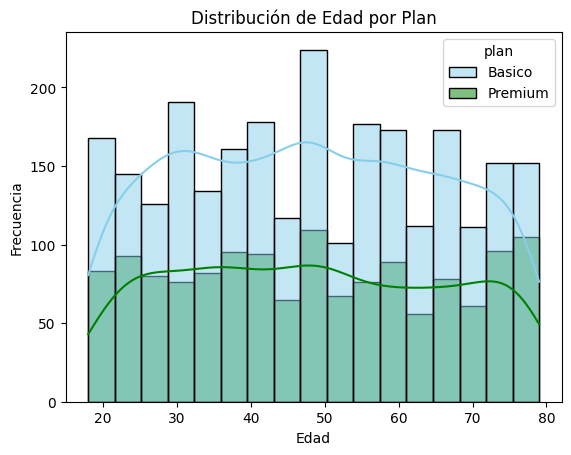

In [99]:

# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución — Es prácticamente uniforme/plana entre 18 y 79 años, sin un pico marcado ni sesgo hacia algún lado (ligeramente simétrica, skew ≈ 0.04–0.07). No hay diferencia relevante en la edad entre planes Básico (media 48.0) y Premium (media 48.3): la edad no parece ser un factor que distinga a los usuarios Premium de los Básico.

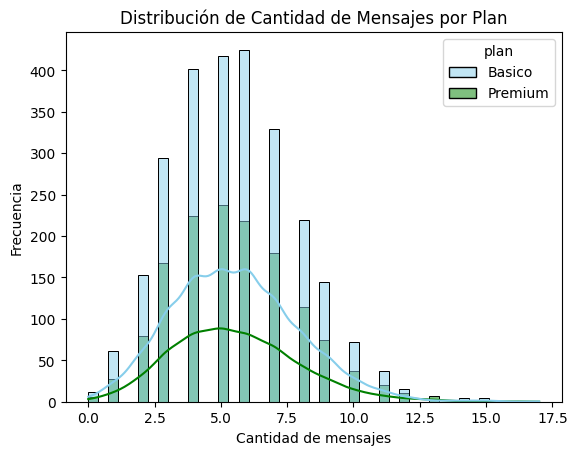

In [100]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Distribución sesgada a la derecha (cola larga hacia valores altos, skew ≈ 0.44–0.49), con la mayoría de usuarios enviando entre 3 y 8 mensajes. Las medias son casi idénticas entre planes (Básico 5.53 vs Premium 5.52) — no existe un patrón diferenciado por tipo de plan en el volumen de mensajes.

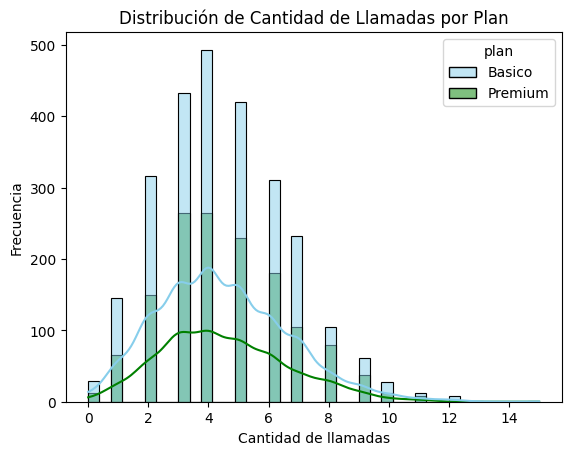

In [101]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Distribución también sesgada a la derecha (skew ≈ 0.45–0.54), concentrada entre 2 y 6 llamadas. De nuevo, medias muy similares entre Básico (4.46) y Premium (4.52) — no hay diferencia relevante en cantidad de llamadas según el plan.

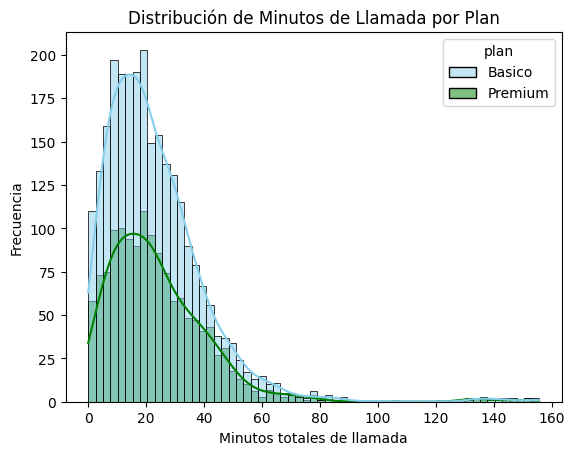

In [102]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Esta es la variable con mayor sesgo a la derecha de las cuatro (skew ≈ 2.45–2.62), con una cola larga hacia valores altos (hasta 155 minutos) — clara señal de posibles outliers que conviene revisar con boxplot en el siguiente paso. Las medias son ligeramente mayores en Premium (24.08 min) vs Básico (22.91 min), pero la diferencia es pequeña y probablemente no significativa dado el traslape casi total de ambas distribuciones.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

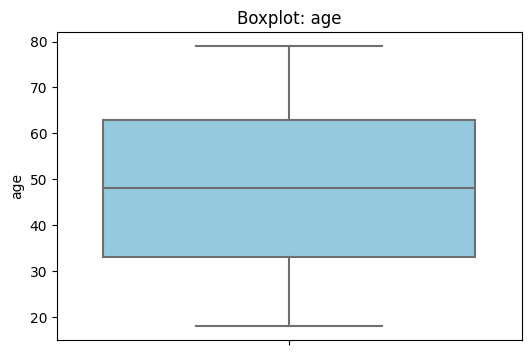

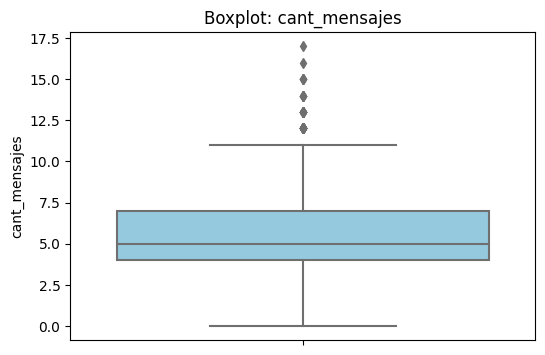

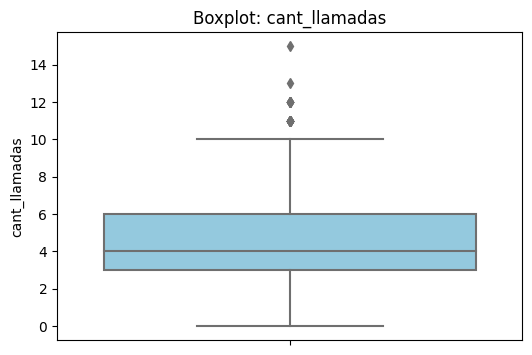

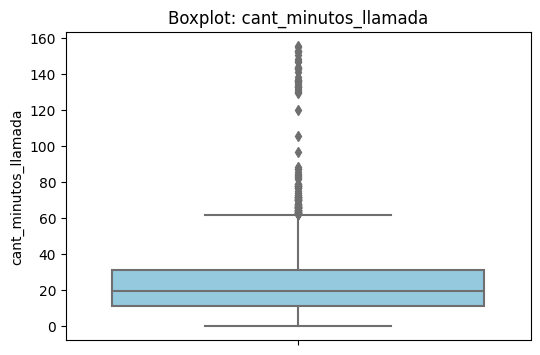

In [103]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age:no presenta outliers, todos los valores caen dentro de los bigotes (rango completo 18-79 sin puntos fuera de rango).
- cant_mensajes:sí presenta outliers, únicamente en el lado superior (usuarios con más de ~11.5 mensajes, hasta 17).
- cant_llamadas:sí presenta outliers, también solo en el lado superior (usuarios con más de ~10.5 llamadas, hasta 15).
- cant_minutos_llamada: presenta la mayor cantidad de outliers y los más extremos, todos en el lado superior (a partir de ~62 minutos, hasta 155.69) — es la variable más sesgada de las cuatro, consistente con lo que vimos en los histogramas.

In [104]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    n_outliers = (user_profile[col] > limite_superior).sum()
    print(f'{col}: limite_superior={limite_superior:.2f}, max={user_profile[col].max()}, n_outliers={n_outliers}')


cant_mensajes: limite_superior=11.50, max=17.0, n_outliers=46
cant_llamadas: limite_superior=10.50, max=15.0, n_outliers=30
cant_minutos_llamada: limite_superior=61.86, max=155.69, n_outliers=109


In [105]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener los outliers. Solo 46 de 4000 usuarios (1.15%) superan el límite, y el máximo (17) no es un valor absurdo — son usuarios reales que simplemente envían más mensajes de lo típico. No hay evidencia de error de captura, así que eliminarlos haría perder información legítima sobre clientes de alto consumo (potenciales candidatos a upsell).
  
- cant_llamadas: mantener los outliers, mismo argumento. 30 usuarios (0.75%) superan el límite, con máximo de 15 llamadas — un valor plausible para un usuario activo, no un error evidente.
  
- cant_minutos_llamada:mantener los outliers, pero con revisión adicional. Aunque 109 usuarios (2.7%) superan el límite y el máximo (155.69 min) es alto, sigue siendo un valor físicamente posible (no es un sentinel tipo -999). Sin embargo, dado que es la variable con más outliers y mayor sesgo, se recomienda no eliminarlos pero sí tratarlos con cuidado en el análisis (por ejemplo, usando la mediana en vez de la media al reportar comportamiento típico, o segmentando aparte a estos usuarios de "alto consumo" como un grupo de interés comercial — podrían ser clientes que se beneficiarían de un plan con más minutos incluidos).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [106]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [107]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [108]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)


In [109]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

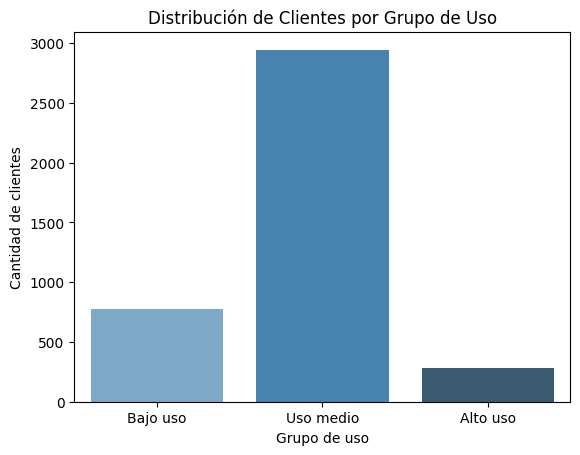

In [112]:


# Visualización de los segmentos por uso
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso, palette='Blues_d')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()

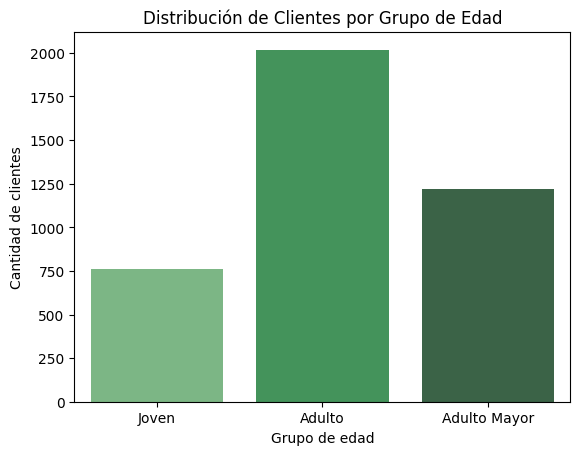

In [113]:

# Visualización de los segmentos por edad
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad, palette='Greens_d')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

users_latam: age tenía sentinel -999 (distorsionaba media/std); city tenía 565 nulos reales (14.1%, combinando NaN y '?'); reg_date con 40 registros (1%) en año futuro 2026; churn_date con 88.35% nulos (normal, son usuarios activos) más un problema de formato de fecha.

usage: duration (55.19%) y length (44.74%) nulos, pero son estructurales (MAR, dependen 99.93% de type), no errores; date con 0.12% nulos, impacto insignificante.


🔍 **Segmentos por Edad**

Por edad: distribución casi uniforme (Adulto 50.5%, Adulto Mayor 30.6%, Joven 19.0%).

Por uso: mayoría en Uso medio (73.6%), y plan (Básico/Premium) no está correlacionado con el consumo real — las distribuciones se traslapan casi por completo.

📊 **Segmentos por Nivel de Uso**

El grupo de "Alto uso" (7%, 279 usuarios), candidatos naturales a upsell.

Los usuarios con plan y uso desalineados (Básico de alto consumo, Premium de bajo consumo), que representan oportunidad de migración.

➡️ Esto sugiere que ...

Los tres con más outliers son cant_mensajes (1.15%), cant_llamadas (0.75%) y sobre todo cant_minutos_llamada (2.7%, hasta 155.69 min).
Se decidió mantenerlos porque son consumo real, no errores — señal de oportunidad comercial, no ruido a limpiar.

💡 **Recomendaciones**

Rediseñar la oferta en torno al uso real, no al plan actual, creando un plan de alto consumo con más minutos/mensajes incluidos.

Lanzar una campaña de migración de plan (upsell a Básico de alto uso, retención a Premium de bajo uso) y mejorar la captura de datos (city, age) para futuras segmentaciones.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`